In [ ]:
!pip install torchmetrics

Downloading Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("adlteam/kaist-dataset")

print("Path to dataset files:", path)

100%|██████████| 18.1G/18.1G [07:51<00:00, 41.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adlteam/kaist-dataset/versions/1


In [ ]:
import os
print("Contents of dataset:")
print(os.listdir(path))

Contents of dataset:


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/adlteam/kaist-dataset/versions/1'

In [ ]:
os.makedirs(output_path, exist_ok=True)

!mv $dataset_path $output_path

print(f"Dataset moved to {output_path}")

Dataset moved to /content/kaist_dataset


In [ ]:
sets = sorted(os.listdir(dataset_path))
print("Available Sets:", sets)

set00_path = os.path.join(dataset_path, "set00")
print("\nExample Files in Set 00:")
print(os.listdir(set00_path))

Available Sets: ['set00', 'set01', 'set02', 'set03', 'set04', 'set05']

Example Files in Set 00:
['V000', 'V007', 'V001', 'V002', 'V005', 'V003', 'V004', 'V008', 'V006']


In [ ]:
import shutil

organized_path = "/content/kaist_organized"
os.makedirs(os.path.join(organized_path, "visible"), exist_ok=True)

def extract_images():
    for set_name in sorted(os.listdir(dataset_path)):
        set_path = os.path.join(dataset_path, set_name)

        for video in sorted(os.listdir(set_path)):
            video_path = os.path.join(set_path, video)
            visible_path = os.path.join(video_path, "visible")

            if os.path.exists(visible_path):
                for img in sorted(os.listdir(visible_path)):
                    shutil.copy(os.path.join(visible_path, img),
                                os.path.join(organized_path, "visible", f"{set_name}_{video}_{img}"))

extract_images()
print(f"All RGB images extracted and saved in {organized_path}")

All RGB images extracted and saved in /content/kaist_organized


In [ ]:
import shutil
original_kaist_path = "/content/kaist_dataset"
shutil.rmtree(original_kaist_path)

To run this next cell: Download kaist-paired.zip linked in google drive and upload it to google colab

In [ ]:
import zipfile

with zipfile.ZipFile("/content/kaist-paired.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/kaist_annotations")

print("Annotations extracted to /content/kaist_annotations")

Annotations extracted to /content/kaist_annotations


In [ ]:
import os
import shutil

visible_img_dir = "/content/kaist_organized/visible"
annotation_root = "/content/kaist_annotations/kaist-paired/annotations"
output_ann_dir = "/content/kaist_visible_annotations"
os.makedirs(output_ann_dir, exist_ok=True)

visible_ids = [
    os.path.splitext(f)[0]
    for f in os.listdir(visible_img_dir) if f.endswith(".jpg")
]

count = 0
for img_id in visible_ids:
    set_name, video_id, frame_id = img_id.split("_")
    anno_file = f"{frame_id}.txt"

    anno_path = os.path.join(annotation_root, set_name, video_id, "visible", anno_file)

    if os.path.exists(anno_path):
        shutil.copy(anno_path, os.path.join(output_ann_dir, f"{img_id}.txt"))
        count += 1

print(f"Copied {count} visible annotations into {output_ann_dir}")

Copied 47264 visible annotations into /content/kaist_visible_annotations


In [ ]:
original_kaist_path = "/content/kaist_annotations"
shutil.rmtree(original_kaist_path)

In [ ]:
LABEL_MAP = {
    "person": 0,
    "cyclist": 1,
    "people": 2
}

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

img_dir = "/content/kaist_organized/visible"
ann_dir = "/content/kaist_visible_annotations"

out_root = "/content/kaist_split"
splits = ['train', 'val', 'test']
for split in splits:
    os.makedirs(os.path.join(out_root, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(out_root, split, 'annotations'), exist_ok=True)

def get_filtered_pairs(set_ids=['set03', 'set04', 'set05']):
    pairs = []
    for fname in os.listdir(img_dir):
        if any(fname.startswith(s) for s in set_ids) and fname.endswith('.jpg'):
            base = fname.replace('.jpg', '')
            ann_file = f"{base}.txt"
            img_path = os.path.join(img_dir, fname)
            ann_path = os.path.join(ann_dir, ann_file)
            if os.path.exists(ann_path):
                pairs.append((img_path, ann_path))
    return pairs

filtered_pairs = get_filtered_pairs()

print(f"Total filtered samples: {len(filtered_pairs)}")

train_val, test = train_test_split(filtered_pairs, test_size=0.15, random_state=42)
train, val = train_test_split(train_val, test_size=0.176, random_state=42)  # ~15% of total

splits_data = {
    'train': train,
    'val': val,
    'test': test
}

for split, items in splits_data.items():
    for img_path, ann_path in items:
        shutil.copy(img_path, os.path.join(out_root, split, 'images', os.path.basename(img_path)))
        shutil.copy(ann_path, os.path.join(out_root, split, 'annotations', os.path.basename(ann_path)))

print("Done splitting and copying KAIST night subsets.")

Total filtered samples: 13865
Done splitting and copying KAIST night subsets.


In [ ]:
DATA_DIR = {
    'train': {
        'images': '/content/kaist_split/train/images',
        'annotations': '/content/kaist_split/train/annotations'
    },
    'val': {
        'images': '/content/kaist_split/val/images',
        'annotations': '/content/kaist_split/val/annotations'
    },
    'test': {
        'images': '/content/kaist_split/test/images',
        'annotations': '/content/kaist_split/test/annotations'
    }
}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mv /content/kaist_split/test /content/drive/MyDrive/

In [ ]:
import os
import torch
from transformers import DeformableDetrForObjectDetection, DeformableDetrImageProcessor
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "SenseTime/deformable-detr"
BATCH_SIZE = 4
LR = 2e-5
NUM_EPOCHS = 10

# Label mapping
LABEL_MAP = {
    'person': 0,
    'people': 1,
    'cyclist': 2
}

model = DeformableDetrForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
).to(DEVICE)

# Deformable Detr's processor
processor = DeformableDetrImageProcessor.from_pretrained(
    MODEL_NAME,
    do_normalize=True,
    image_mean=[0.485, 0.456, 0.406],
    image_std=[0.229, 0.224, 0.225],
    size={"shortest_edge": 600, "longest_edge": 1333},
    do_resize=True
)

UNFREEZE_KEYS = [
    "class_embed",
    "bbox_embed",
    "model.decoder",
    "model.backbone.conv_encoder.model.layer4",
    "model.input_proj"
]

# Freeze all layers except those in UNFREEZE_KEYS
for name, param in model.named_parameters():
    param.requires_grad = any(key in name for key in UNFREEZE_KEYS)

print("Trainable parameters:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print("unfrozen: ", name)
print(f"Total trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Converting annotations to COCO json style for it to be compatible with Deformable DETR
def convert_txt_annotation_to_detr(txt_path, img_path, image_id):
    with open(txt_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip() and not line.startswith('%')]

    with Image.open(img_path) as img:
        width, height = img.size

    annotations = []
    for ann_id, line in enumerate(lines):
        parts = line.split()
        if len(parts) < 5:
            continue

        cls_name = parts[0]
        if cls_name not in LABEL_MAP:
            continue

        x_min, y_min, box_width, box_height = map(float, parts[1:5])

        annotations.append({
            "id": ann_id,
            "bbox": [x_min, y_min, box_width, box_height],
            "area": box_width * box_height,
            "category_id": LABEL_MAP[cls_name],
            "iscrowd": 0,
            "image_id": image_id,
            "segmentation": []
        })

    return {
        "image_id": image_id,
        "annotations": annotations,
        "width": width,
        "height": height,
        "orig_size": (height, width)
    }

class KaistDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, processor):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.processor = processor
        all_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])

        self.image_files = []
        for f in all_files:
            ann_path = os.path.join(annotation_dir, os.path.splitext(f)[0] + '.txt')
            img_path = os.path.join(image_dir, f)
            target = convert_txt_annotation_to_detr(ann_path, img_path, image_id=0)
            if len(target["annotations"]) > 0:
                self.image_files.append(f)

        print(f"Filtered dataset: {len(self.image_files)} images with at least 1 annotation.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        annotation_path = os.path.join(self.annotation_dir,
                                    os.path.splitext(self.image_files[idx])[0] + '.txt')

        target = convert_txt_annotation_to_detr(annotation_path, image_path, idx)
        image = Image.open(image_path).convert("RGB")

        processed = processor(
        images=image,
        annotations=target,
        return_tensors="pt"
        )

        pixel_values = processed["pixel_values"].squeeze(0)

        return {
            "pixel_values": pixel_values,
            "pixel_mask": processed["pixel_mask"].squeeze(0),
            "labels": processed["labels"][0]
        }


def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    pixel_mask = torch.stack([item["pixel_mask"] for item in batch])
    labels = [item["labels"] for item in batch]

    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "labels": labels
    }

def create_dataloaders():
    train_dataset = KaistDataset(
        DATA_DIR['train']['images'],
        DATA_DIR['train']['annotations'],
        processor
    )
    val_dataset = KaistDataset(
        DATA_DIR['val']['images'],
        DATA_DIR['val']['annotations'],
        processor
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                            shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

    return train_loader, val_loader

train_loader, val_loader = create_dataloaders()
optimizer = AdamW(params=[p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=1e-4)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are ini

Trainable parameters:
unfrozen:  model.backbone.conv_encoder.model.layer4.0.conv1.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.0.conv2.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.0.conv3.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.0.downsample.0.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.1.conv1.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.1.conv2.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.1.conv3.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.2.conv1.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.2.conv2.weight
unfrozen:  model.backbone.conv_encoder.model.layer4.2.conv3.weight
unfrozen:  model.input_proj.0.0.weight
unfrozen:  model.input_proj.0.0.bias
unfrozen:  model.input_proj.0.1.weight
unfrozen:  model.input_proj.0.1.bias
unfrozen:  model.input_proj.1.0.weight
unfrozen:  model.input_proj.1.0.bias
unfrozen:  model.input_proj.1.1.weight
unfrozen:  model.input_proj.1.1.bi

In [ ]:
batch = next(iter(train_loader))
print("Pixel values range:", batch["pixel_values"].min(), batch["pixel_values"].max())  # Should be ~[-1, 1]
print("Sample label:", batch["labels"][0])  # Check bbox values are normalized

Pixel values range: tensor(-2.1179) tensor(2.6400)
Sample label: {'size': tensor([600, 750]), 'image_id': tensor([2221]), 'class_labels': tensor([0, 0, 1, 0, 0, 0, 0]), 'boxes': tensor([[0.9281, 0.5127, 0.0500, 0.1934],
        [0.7461, 0.4717, 0.0328, 0.0996],
        [0.1297, 0.4307, 0.1813, 0.0723],
        [0.2492, 0.4307, 0.0234, 0.0684],
        [0.2688, 0.4307, 0.0250, 0.0723],
        [0.3141, 0.4336, 0.0312, 0.0664],
        [0.3922, 0.4277, 0.0312, 0.0703]]), 'area': tensor([4350.5859, 1470.7947, 5894.1650,  720.9778,  812.9883,  933.8379,
         988.7695]), 'iscrowd': tensor([0, 0, 0, 0, 0, 0, 0]), 'orig_size': tensor([512, 640])}


In [ ]:
from torch.cuda.amp import autocast, GradScaler
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from transformers import get_scheduler

# Function to convert from normalized to absolute for groundtruth
def cxcywh_to_xyxy(boxes, size):
    h, w = size
    boxes = boxes.clone()
    cx, cy, bw, bh = boxes.unbind(-1)
    x1 = (cx - bw / 2) * w
    y1 = (cy - bh / 2) * h
    x2 = (cx + bw / 2) * w
    y2 = (cy + bh / 2) * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

def train_detr(model, train_loader, val_loader, processor, optimizer, num_epochs=10, save_path="RGB_Deformable_DETR.pth"):
    scaler = GradScaler()
    metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])
    lr_scheduler = get_scheduler(
        name="linear",
        optimizer=optimizer,
        num_warmup_steps=100,
        num_training_steps=num_epochs * len(train_loader)
    )

    best_val_loss = float('inf')
    no_improve = 0
    min_epochs = 2
    patience = 3

    for epoch in range(num_epochs):
        model.train()
        epoch_stats = {"total": 0.0, "class": 0.0, "bbox": 0.0, "giou": 0.0}

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            pixel_values = batch["pixel_values"].to(DEVICE)
            pixel_mask = batch["pixel_mask"].to(DEVICE)
            labels = batch["labels"]

            targets = [{
                "class_labels": label["class_labels"].to(DEVICE),
                "boxes": label["boxes"].to(DEVICE)
            } for label in labels]

            optimizer.zero_grad()
            with autocast():
                outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=targets)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            scaler.step(optimizer)
            scaler.update()
            lr_scheduler.step()

            epoch_stats["total"] += loss.item()
            loss_name_map = {
                "loss_ce": "class",
                "loss_bbox": "bbox",
                "loss_giou": "giou"
            }
            for k, display_name in loss_name_map.items():
                if k in outputs.loss_dict:
                    epoch_stats[display_name] += outputs.loss_dict[k].item()

        avg_train_loss = epoch_stats["total"] / len(train_loader)

        # ---- Validation Phase ----
        model.eval()
        val_loss = 0.0
        metric.reset()

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validation"):
                pixel_values = batch["pixel_values"].to(DEVICE)
                pixel_mask = batch["pixel_mask"].to(DEVICE)
                labels = batch["labels"]

                targets = [{
                    "class_labels": label["class_labels"].to(DEVICE),
                    "boxes": label["boxes"].to(DEVICE)
                } for label in labels]

                with autocast():
                    outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=targets)

                val_loss += outputs.loss.item()

                orig_sizes = [label["orig_size"] for label in batch["labels"]]
                results = processor.post_process_object_detection(outputs, target_sizes=orig_sizes, threshold=0.1)

                preds = [{
                    "boxes": r["boxes"].cpu(),
                    "scores": r["scores"].cpu(),
                    "labels": r["labels"].cpu()
                } for r in results]

                gts = []
                for t in labels:
                    size = t["orig_size"]
                    gt_boxes = cxcywh_to_xyxy(t["boxes"].cpu(), size)
                    gts.append({
                        "boxes": gt_boxes,
                        "labels": t["class_labels"].cpu()
                    })

                metric.update(preds, gts)

        avg_val_loss = val_loss / len(val_loader)
        val_map = metric.compute()["map_50"].item()

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"Train Loss: {avg_train_loss:.4f} | Cls: {epoch_stats['class']:.2f} | BBox: {epoch_stats['bbox']:.2f} | GIoU: {epoch_stats['giou']:.2f}")
        print(f"Val Loss: {avg_val_loss:.4f} | mAP@0.5: {val_map:.4f}")

        if epoch >= min_epochs:
            if avg_val_loss < best_val_loss * 0.999:
                best_val_loss = avg_val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': avg_val_loss,
                    'map_50': val_map
                }, save_path)
                no_improve = 0
                print(f"Saved best model (Val Loss: {avg_val_loss:.4f}, mAP@0.5: {val_map:.4f})")
            else:
                no_improve += 1
                print(f"▁ No improvement ({no_improve}/{patience})")
                if no_improve >= patience:
                    print("Early stopping triggered.")
                    break
        else:
            print("Skipping early stop check (min_epochs not reached).")

In [ ]:
train_detr(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    processor=processor,
    optimizer=optimizer,
    num_epochs=15,
    save_path="RGB_Finetuned.pth"
)

<ipython-input-10-7e5bd2fb00ab>:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1 Training:   0%|          | 0/1085 [00:00<?, ?it/s]<ipython-input-10-7e5bd2fb00ab>:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation:   0%|          | 0/229 [00:00<?, ?it/s]<ipython-input-10-7e5bd2fb00ab>:84: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 229/229 [02:07<00:00,  1.79it/s]



Epoch 1 Summary:
Train Loss: 3.1029 | Cls: 2426.67 | BBox: 42.95 | GIoU: 362.60
Val Loss: 1.1018 | mAP@0.5: 0.2059
Skipping early stop check (min_epochs not reached).


Validation: 100%|██████████| 229/229 [02:05<00:00,  1.83it/s]



Epoch 2 Summary:
Train Loss: 0.9862 | Cls: 355.01 | BBox: 30.30 | GIoU: 281.74
Val Loss: 0.9717 | mAP@0.5: 0.2471
Skipping early stop check (min_epochs not reached).


Validation: 100%|██████████| 229/229 [02:04<00:00,  1.84it/s]


...


Epoch 9 Summary:
Train Loss: 0.5881 | Cls: 160.86 | BBox: 18.50 | GIoU: 192.38
Val Loss: 0.6841 | mAP@0.5: 0.6243
Saved best model (Val Loss: 0.6841, mAP@0.5: 0.6243)


Validation: 100%|██████████| 229/229 [02:02<00:00,  1.86it/s]



Epoch 10 Summary:
Train Loss: 0.5678 | Cls: 152.59 | BBox: 17.78 | GIoU: 187.32
Val Loss: 0.6770 | mAP@0.5: 0.6394
Saved best model (Val Loss: 0.6770, mAP@0.5: 0.6394)


Epoch 11 Training:  11%|█         | 115/1085 [01:49<15:22,  1.05it/s]


KeyboardInterrupt: 

To run this next cell load RGB_Finetuned.pth from drive

In [ ]:
checkpoint = torch.load("RGB_Finetuned.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

DeformableDetrForObjectDetection(
  (model): DeformableDetrModel(
    (backbone): DeformableDetrConvModel(
      (conv_encoder): DeformableDetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DeformableDetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DeformableDetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DeformableDetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3):

In [ ]:
test_dataset = KaistDataset(
    DATA_DIR['test']['images'],
    DATA_DIR['test']['annotations'],
    processor
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

Filtered dataset: 916 images with at least 1 annotation.


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def cxcywh_to_xyxy(boxes, size):
    h, w = size
    boxes = boxes.clone()
    cx, cy, bw, bh = boxes.unbind(-1)
    x1 = (cx - bw / 2) * w
    y1 = (cy - bh / 2) * h
    x2 = (cx + bw / 2) * w
    y2 = (cy + bh / 2) * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])
model.eval()

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(DEVICE)
        pixel_mask = batch["pixel_mask"].to(DEVICE)
        labels = batch["labels"]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        orig_sizes = [label["orig_size"] for label in labels]
        results = processor.post_process_object_detection(outputs, target_sizes=orig_sizes, threshold=0.1)

        # Preparing predictions
        preds = [{
            "boxes": r["boxes"].cpu(),
            "scores": r["scores"].cpu(),
            "labels": r["labels"].cpu()
        } for r in results]

        # Converting GT boxes to [x1, y1, x2, y2]
        gts = []
        for t in labels:
            h, w = t["orig_size"]
            boxes = cxcywh_to_xyxy(t["boxes"], t["orig_size"])  # still in [0–1]
            gts.append({
                  "boxes": boxes.cpu(),
                  "labels": t["class_labels"].cpu()
            })

        metric.update(preds, gts)

final_map = metric.compute()
print("Final Test mAP Results:")

for k, v in final_map.items():
    if isinstance(v, torch.Tensor) and v.ndim == 0:
        print(f"{k}: {v.item():.4f}")
    else:
        print(f"{k}: {v}")

Final Test mAP Results:
map: 0.5500
map_50: 0.5500
map_75: -1.0000
map_small: 0.2865
map_medium: 0.5964
map_large: 0.7491
mar_1: 0.3947
mar_10: 0.8159
mar_100: 0.8745
mar_small: 0.7731
mar_medium: 0.8853
mar_large: 0.9000
map_per_class: -1.0000
mar_100_per_class: -1.0000
classes: tensor([0, 1, 2], dtype=torch.int32)


Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DeformableDetrForObjectDetection wer

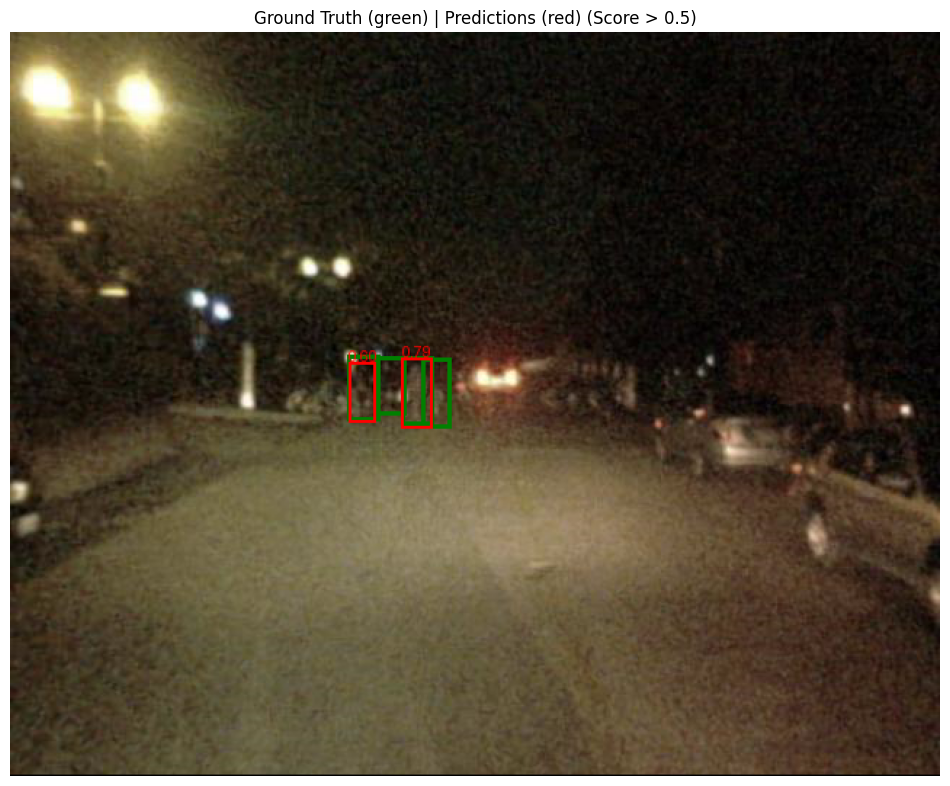

In [ ]:
import torch
from PIL import Image, ImageDraw
from transformers import DeformableDetrForObjectDetection, DeformableDetrImageProcessor
import matplotlib.pyplot as plt
import os

# Loading Model and processor
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = DeformableDetrForObjectDetection.from_pretrained(
    "SenseTime/deformable-detr",
    num_labels=3,
    ignore_mismatched_sizes=True
).to(DEVICE)

checkpoint = torch.load("RGB_Finetuned.pth", map_location=torch.device("cpu"))
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE).eval()

processor = DeformableDetrImageProcessor.from_pretrained("SenseTime/deformable-detr")

LABEL_MAP = {
    'person': 0,
    'people': 1,
    'cyclist': 2
}

def load_annotation(txt_path, image_id, width, height):
    with open(txt_path, "r") as f:
        lines = [line.strip() for line in f if line.strip() and not line.startswith('%')]

    annotations = []
    for idx, line in enumerate(lines):
        parts = line.split()
        if parts[0] not in LABEL_MAP: continue
        x, y, w, h = map(float, parts[1:5])
        annotations.append({
            "id": idx,
            "bbox": [x, y, w, h],
            "category_id": LABEL_MAP[parts[0]],
            "area": w * h,
            "iscrowd": 0,
            "image_id": image_id,
            "segmentation": []
        })

    return {
        "image_id": image_id,
        "annotations": annotations,
        "width": width,
        "height": height,
        "orig_size": (height, width)
    }

# Loading image and annotation (you can find these 2 in drive)
image_path = "set03_V000_I00066.jpg"
ann_path = "set03_V000_I00066.txt"

image = Image.open(image_path).convert("RGB")
W, H = image.size
annotation = load_annotation(ann_path, image_id=0, width=W, height=H)

# Run inference
inputs = processor(images=image, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)
    results = processor.post_process_object_detection(outputs, target_sizes=[(H, W)], threshold=0.1)[0]

# Visualize results
draw = ImageDraw.Draw(image)

#Ground Truth
for gt in annotation["annotations"]:
    x, y, w, h = gt["bbox"]
    draw.rectangle([x, y, x+w, y+h], outline="green", width=3)

#Predictions
boxes = results["boxes"]
scores = results["scores"]
labels = results["labels"]

for box, score in zip(boxes, scores):
    if score < 0.5: continue
    x1, y1, x2, y2 = box.tolist()
    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
    draw.text((x1, y1 - 10), f"{score:.2f}", fill="red")

plt.figure(figsize=(12, 10))
plt.imshow(image)
plt.title("Ground Truth (green) | Predictions (red) (Score > 0.5)")
plt.axis("off")
plt.show()

In [ ]:
import torch
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def cxcywh_to_xyxy(boxes, size):
    h, w = size
    boxes = boxes.clone()
    cx, cy, bw, bh = boxes.unbind(-1)
    x1 = (cx - bw / 2) * w
    y1 = (cy - bh / 2) * h
    x2 = (cx + bw / 2) * w
    y2 = (cy + bh / 2) * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

def evaluate_detr_rgb(model, test_loader, processor):
    # Load the RGB-finetuned model checkpoint
    checkpoint = torch.load("/content/RGB_Finetuned.pth", map_location="cuda")
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])
    metric.to(model.device)

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating RGB-Finetuned Model"):
            pixel_values = batch["pixel_values"].to(model.device)
            pixel_mask = batch["pixel_mask"].to(model.device)
            labels = batch["labels"]

            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

            orig_sizes = [l["orig_size"] for l in labels]
            target_sizes = torch.stack([torch.tensor(size) for size in orig_sizes]).to(model.device)

            results = processor.post_process_object_detection(
                outputs=outputs,
                target_sizes=target_sizes,
                threshold=0.1
            )

            preds = [{
                "boxes": r["boxes"].cpu(),
                "scores": r["scores"].cpu(),
                "labels": r["labels"].cpu()
            } for r in results]

            gts = [{
                "boxes": cxcywh_to_xyxy(t["boxes"].cpu(), t["orig_size"]),
                "labels": t["class_labels"].cpu()
            } for t in labels]

            metric.update(preds, gts)

    final_metrics = metric.compute()
    print("\nEvaluation Metrics (RGB-Finetuned):")
    print(f"mAP@0.5: {final_metrics['map_50']:.4f}")

    return final_metrics

In [ ]:
val_metrics = evaluate_detr_rgb(model, test_loader, processor)

Evaluating RGB-Finetuned Model:   0%|          | 0/916 [00:00<?, ?it/s]<ipython-input-20-e7e90e98527c>:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_sizes = torch.stack([torch.tensor(size) for size in orig_sizes]).to(model.device)
Evaluating RGB-Finetuned Model: 100%|██████████| 916/916 [04:41<00:00,  3.26it/s]



Evaluation Metrics (RGB-Finetuned):
mAP@0.5: 0.5500
